In [2]:
from itu.algs4.graphs.digraph import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gzip
import powerlaw
import cv2

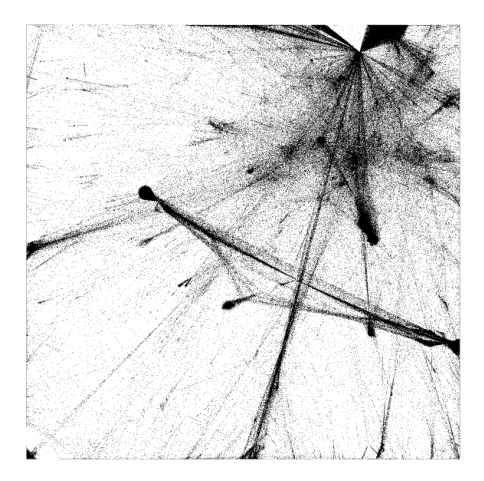

In [ ]:
# Exibir imagem do grafo (Gephi)

image = cv2.imread("../Captura de tela 2026-02-25 081353.png")

# Converter a imagem de BGR para RGB (OpenCV usa BGR por padrão)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Exibir a imagem usando Matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis('off')  # Ocultar os eixos
plt.show()

## 1. Sobre o grafo
Os **vértices** representam páginas de [Stanford University](https://Stanford.edu) (Stanford.edu), e as **arestas direcionadas** representam links entre elas.

| **Dataset info** |  | |
| --- | --- | --- |
| Vértices — $V$ | 281903 | |
| Arestas — $E$ | 2312497 | direcionadas |
| Tipo de grafo | ? | |
| Densidade — $\rho$ | 0.0000291 | esparso |
| Grau médio (in/out) — $d(G)$ | 8.20 | |

## 2. Leitura do arquivo
O arquivo contendo a lista de arestas é carregado em .txt.gz <br>
As primeiras linhas incluem comentários nos quais são identificados o número de vértices e arestas do grafo.
```
# Directed graph (each unordered pair of nodes is saved once): web-Stanford.txt 
# Stanford web graph from 2002
# Nodes: 281903 Edges: 2312497
# FromNodeId	ToNodeId
```
As linhas seguintes contêm as arestas no formato: vertice1 vertice2

In [3]:
def load_graph_from_file(file_path):
    with gzip.open(file_path, 'rt') as f:
        # Ler as linhas do arquivo
        lines = f.readlines()
        
        # Ignorar as linhas de comentário e extrair o número de vértices e arestas
        for line in lines:
            if line.startswith('#'):
                if 'Nodes:' in line and 'Edges:' in line:
                    parts = line.split()
                    v = int(parts[2])
                    E = int(parts[4])
                    break
        
        # criar Dataframe para armazenar as arestas
        edges = []
        for line in lines:
            if not line.startswith('#'):
                parts = line.split()
                if len(parts) == 2:
                    v1 = int(parts[0])
                    v2 = int(parts[1])
                    edges.append((v1, v2))
        df_edges = pd.DataFrame(edges, columns=['Source', 'Target'])


        # Criar um grafo dirigido com o número de vértices
        G = Digraph(v, first_index=min(df_edges['Source']))
        
        # Adicionar as arestas ao grafo
        for line in lines:
            if not line.startswith('#'):
                parts = line.split()
                if len(parts) == 2:
                    v1 = int(parts[0])
                    v2 = int(parts[1])
                    G.add_edge(v1, v2)
    
    return G, df_edges

G, df_edges = load_graph_from_file('./files/web-Stanford.txt.gz')
in_degrees = [G.in_degree(v) for v in range(min(df_edges['Source']), G.V() + min(df_edges['Source']))]
out_degrees = [G.out_degree(v) for v in range(min(df_edges['Source']), G.V() + min(df_edges['Source']))]

print(f"Número de vértices: {G.V()}")
print(f"Número de arestas: {G.E()}")
print(f"Multigrafo: {is_multi_digraph(G, min(df_edges['Source']))}")

Número de vértices: 281903
Número de arestas: 2312497
Multigrafo: False


## 3. Salvar arquivo em .csv e lista de in-degree/out-degree
O arquivo carregado é salvo em formato .csv compatível com o software Gephi. <br>
As listas do grau (in-degree, out-degree) por vértice são salvas para análise de distribuição.

In [9]:
# Salvar o DataFrame em um arquivo CSV
df_edges.to_csv('./files/edges.csv', index=False)

# Salvar lista de in-degrees e out-degrees
pd.DataFrame({'In-Degree': in_degrees, 'Out-Degree': out_degrees}).to_csv('./files/degrees.csv', index=False)

## 4. Densidade
Encontrada a partir da fórmula:
$ \ \rho = \frac{E}{V(V-1)} $ 
<br>
Onde $ \rho \rightarrow 1 $ indica um grafo **denso**; <br>
E $ \rho \rightarrow 0 $ indica um grafo **esparso**.

In [10]:
print(f"Densidade: {G.density():.9f}")

Densidade: 0.000029099


## 5. Distribuição de graus

In [4]:
max_in_degree = max(in_degrees)
max_out_degree = max(out_degrees)

min_in_degree = min(in_degrees)
min_out_degree = min(out_degrees)

avg_in_degree = sum(in_degrees) / len(in_degrees)
avg_out_degree = sum(out_degrees) / len(out_degrees)

print("="*20)
print(f"max in-degree: {max_in_degree}\nmin in-degree: {min_in_degree}")
print(f"avg in-degree: {avg_in_degree:.2f}")
print("="*20)
print(f"max out-degree: {max_out_degree}\nmin out-degree: {min_out_degree}")
print(f"avg out-degree: {avg_out_degree:.2f}")
print("="*20)

# in_degree_variance = np.var(in_degrees)
# out_degree_variance = np.var(out_degrees)
# print(f"variância in-degree: {in_degree_variance:.2f}")
# print(f"variância out-degree: {out_degree_variance:.2f}")

max in-degree: 38606
min in-degree: 0
avg in-degree: 8.20
max out-degree: 255
min out-degree: 0
avg out-degree: 8.20


### 5.1. Histograma

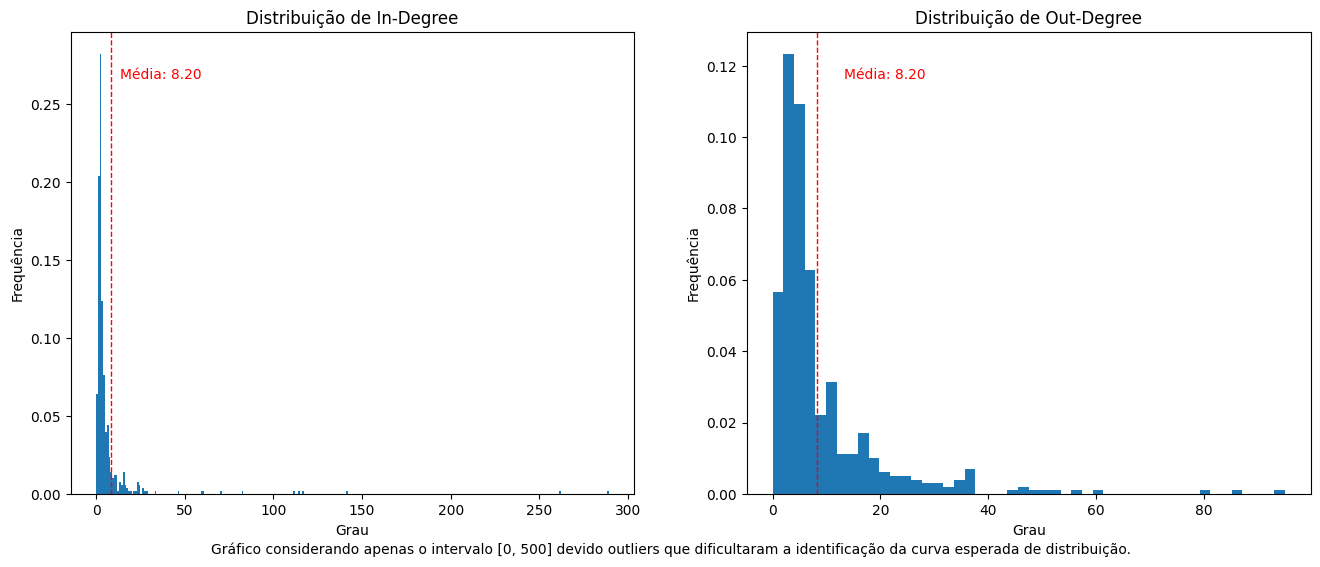

In [27]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.hist(in_degrees[:500], bins="fd", density=True)
plt.title("Distribuição de In-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_in_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_in_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_in_degree:.2f}', color='red')

plt.subplot(1,2,2)
plt.hist(out_degrees[:500], bins="fd", density=True)
plt.title("Distribuição de Out-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_out_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_out_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_out_degree:.2f}', color='red')

plt.figtext(0.5, 0.01, "Gráfico considerando apenas o intervalo [0, 500] devido outliers que dificultaram a identificação da curva esperada de distribuição.", ha="center")

plt.show()

### 5.2. Gráfico de dispersão

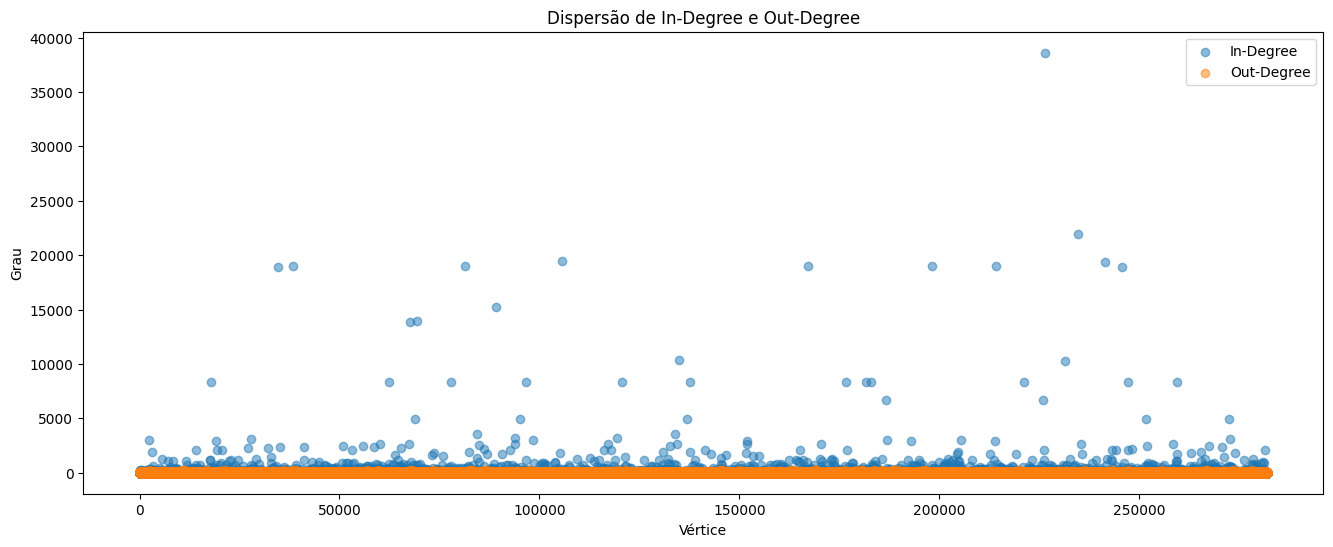

In [13]:
# plotar dispersão de graus
plt.figure(figsize=(16,6))

plt.scatter(range(len(in_degrees)), in_degrees, alpha=0.5, label="In-Degree")
plt.scatter(range(len(out_degrees)), out_degrees, alpha=0.5, label="Out-Degree")
plt.title("Dispersão de In-Degree e Out-Degree")
plt.xlabel("Vértice")
plt.ylabel("Grau")
plt.legend()

plt.show()

### 5.3. Ajuste a Power Law / Log Normal

In [5]:
results = powerlaw.Fit(in_degrees, discrete=True)
results_out = powerlaw.Fit(out_degrees, discrete=True)


c:\Users\Gabriel\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw\fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 629/629 [00:02<00:00, 215.25it/s]
c:\Users\Gabriel\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw\fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 187/187 [00:02<00:00, 87.63it/s] 


In [6]:
print("In-degree:")
print("Alpha:", results.power_law.alpha)
print("Xmin:", results.power_law.xmin)

print("Out-degree:")
print("Alpha:", results_out.power_law.alpha)
print("Xmin:", results_out.power_law.xmin)

In-degree:
Alpha: 2.1484179120002604
Xmin: 3.0
Out-degree:
Alpha: 2.2907200251392563
Xmin: 5.0


### Plot do gráfico log-log:

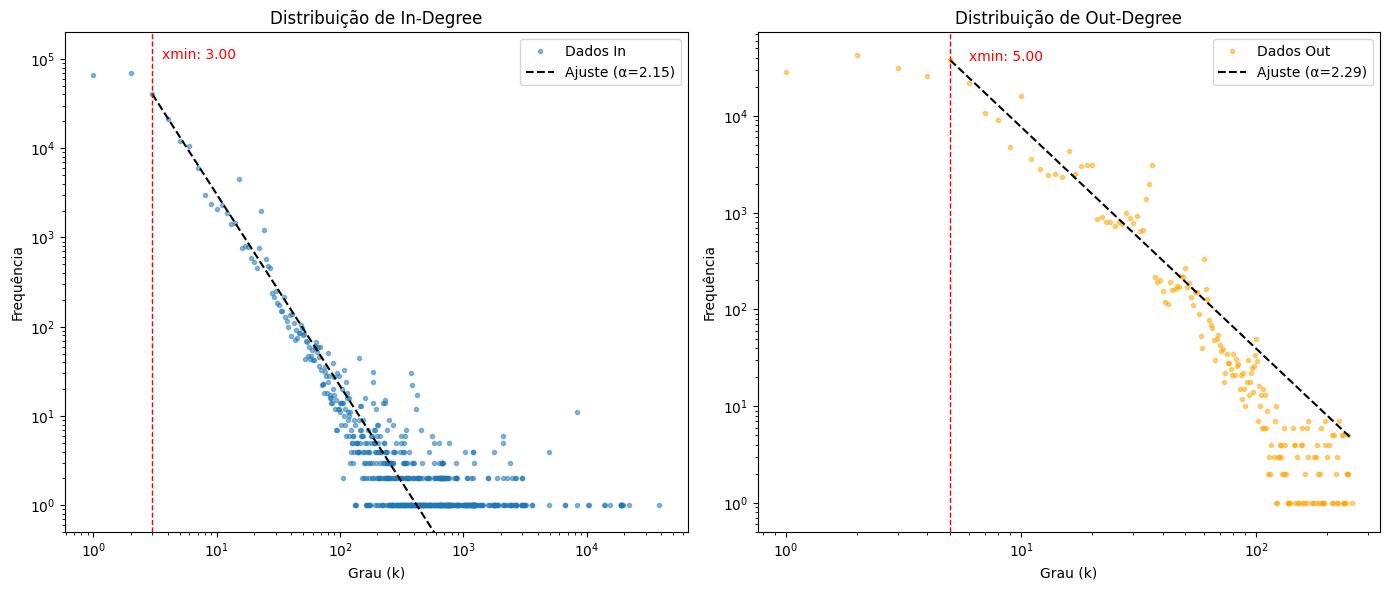

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# --- Gráfico 1: In-Degree ---
# ==========================================
degree_count = np.bincount(in_degrees)
degrees = np.arange(len(degree_count))
mask_in = degree_count > 0
ax[0].loglog(degrees[mask_in], degree_count[mask_in], marker=".", linestyle="None", alpha=0.5, label='Dados In')

# 1. Parâmetros do modelo In-Degree
xmin_in = results.power_law.xmin
alpha_in = results.power_law.alpha

# 2. Gerar pontos para a linha (do xmin até o grau máximo)
x_fit_in = np.linspace(xmin_in, max(degrees), 100)

# 3. Encontrar a constante (C) ancorando a linha no primeiro dado real a partir do xmin
idx_in = np.where(degrees[mask_in] >= xmin_in)[0][0]
anchor_x_in = degrees[mask_in][idx_in]
anchor_y_in = degree_count[mask_in][idx_in]
C_in = anchor_y_in * (anchor_x_in ** alpha_in)

# 4. Calcular e plotar a linha manual
y_fit_in = C_in * (x_fit_in ** -alpha_in)
ax[0].plot(x_fit_in, y_fit_in, color='black', linestyle='--', label=f'Ajuste (α={alpha_in:.2f})')
ax[0].set_ylim(bottom=0.5)

# Estética In-Degree
ax[0].axvline(xmin_in, color='red', linestyle='dashed', linewidth=1)
ax[0].text(xmin_in * 1.2, ax[0].get_ylim()[1]*0.5, f'xmin: {xmin_in:.2f}', color='red')
ax[0].set_title("Distribuição de In-Degree")
ax[0].set_xlabel("Grau (k)"), ax[0].set_ylabel("Frequência"), ax[0].legend()


# ==========================================
# --- Gráfico 2: Out-Degree ---
# ==========================================
degree_count_out = np.bincount(out_degrees)
degrees_out = np.arange(len(degree_count_out))
mask_out = degree_count_out > 0
ax[1].loglog(degrees_out[mask_out], degree_count_out[mask_out], marker=".", linestyle="None", alpha=0.5, color='orange', label='Dados Out')

# 1. Parâmetros do modelo Out-Degree
xmin_out = results_out.power_law.xmin
alpha_out = results_out.power_law.alpha

# 2. Gerar pontos para a linha 
x_fit_out = np.linspace(xmin_out, max(degrees_out), 100)

# 3. Encontrar a constante (C) ancorando a linha
idx_out = np.where(degrees_out[mask_out] >= xmin_out)[0][0]
anchor_x_out = degrees_out[mask_out][idx_out]
anchor_y_out = degree_count_out[mask_out][idx_out]
C_out = anchor_y_out * (anchor_x_out ** alpha_out)

# 4. Calcular e plotar a linha manual
y_fit_out = C_out * (x_fit_out ** -alpha_out)
ax[1].plot(x_fit_out, y_fit_out, color='black', linestyle='--', label=f'Ajuste (α={alpha_out:.2f})')
# LImite minimo do eixo Y para evitar que a linha de ajuste fique muito baixa e difícil de visualizar
ax[1].set_ylim(bottom=0.5)

# Estética Out-Degree
ax[1].axvline(xmin_out, color='red', linestyle='dashed', linewidth=1)
ax[1].text(xmin_out * 1.2, ax[1].get_ylim()[1]*0.5, f'xmin: {xmin_out:.2f}', color='red')
ax[1].set_title("Distribuição de Out-Degree")
ax[1].set_xlabel("Grau (k)"), ax[1].set_ylabel("Frequência"), ax[1].legend()

plt.tight_layout()
plt.show()

### Comparação das distribuições:

In [16]:
print("Comparação In-Degree:")
R, p = results.distribution_compare('power_law', 'lognormal')
print(R) 
print(f"{p:.12f}") 
print("Comparação Out-Degree:")
R_out, p_out = results_out.distribution_compare('power_law', 'lognormal')
print(R_out)
print(f"{p_out:.12f}")

Comparação In-Degree:
-14.691859684735814
0.000000000000
Comparação Out-Degree:
-1412.7084038829041
0.000000000000


### 5.4. Interpretação dos resultados

Os números impressos na célula anterior são:

- `alpha` e `xmin` vêm do objeto `results.power_law`. `alpha` é o expoente da lei de potência ajustada, ou seja, o parâmetro que determina a inclinação na escala log‑log. Valores típicos para redes reais ficam entre 2 e 3. `xmin` é o grau mínimo a partir do qual a lei de potência foi considerada pelo ajuste; dados abaixo desse valor são ignorados no cálculo do `alpha`.

- `R` é o **logaritmo da razão de verossimilhança** (log likelihood ratio) entre os dois modelos comparados. É o valor que indica qual modelo tem verossimilhança maior.
- `p` é o **p‑value** associado ao teste de razão de verossimilhança. Ele quantifica quão provável é observar um `R` tão extremo sob a hipótese nula de que ambos os modelos descrevem igualmente bem os dados.
- `R` e `p` são retornados por `results.distribution_compare('power_law', 'lognormal')`.
  - `R` é o logaritmo da razão de verossimilhança entre os dois modelos. Um valor **positivo** indica que os dados são mais compatíveis com a lei de potência do que com a lognormal; um valor **negativo** favoreceria a lognormal.
  - `p` é a probabilidade de obter uma diferença de verossimilhança tão extrema (ou mais) sob a hipótese nula de que *ambos* os modelos são igualmente bons. Um `p` pequeno (tipicamente < 0.05) significa que a preferência medida em `R` não é apenas ruído estatístico, indicando que a vantagem da potência não é aleatória.

Em resumo, os valores obtidos sugerem que a distribuição de graus **segue melhor uma lognormal**, com expoente `alpha` (veja saída acima) e um ponto de corte `xmin` abaixo do qual a fitting foi feito. A escolha final sempre deve considerar o contexto do problema e inspeção visual do ajuste (plot log‑log).  

<!-- Se quiser comparar com outros candidatos (ex.: exponencial), basta passar o nome desejado para `distribution_compare`. -->

### 5.5. Comparação com dados de referência
<!-- 
#### Análise Comparativa: Propriedades Topológicas da Rede (Dataset Stanford vs. WWW)

Ao analisar redes complexas direcionadas, como a World Wide Web (WWW), a distribuição das conexões de entrada (In-degree) e de saída (Out-degree) revela características fundamentais sobre o comportamento e a evolução do sistema. Neste trabalho, comparamos os parâmetros de distribuição de grau obtidos a partir de um dataset da Universidade de Stanford com os valores de referência da rede WWW documentados na literatura clássica de redes complexas.

##### 1. Distribuição de In-Degree ($\alpha_{in}$ / $\gamma_{in}$)

A distribuição de In-degree reflete a popularidade ou a autoridade dos nós dentro da rede (quantos links apontam para uma página). 
* **Dados da Literatura (WWW):** O valor característico encontrado é $\gamma_{in}$ = **2.00**.
* **Dataset Stanford:** O parâmetro ajustado (Alpha) obtido foi $\alpha_{in} \approx$ **2.15** (com $x_{min}$ = **3.0**).

**Interpretação:** Ambos os valores situam-se no intervalo de $2 < \alpha < 3$, o que é uma forte indicação de uma rede do tipo *Scale-Free* (livre de escala). O valor obtido no nosso dataset (2.15) está muito próximo ao valor de referência da WWW (2.00). Isso significa que, assim como na Web real, a rede analisada possui uma vasta maioria de nós com pouquíssimas conexões de entrada, enquanto um número muito reduzido de "hubs" concentra uma quantidade massiva de links direcionados a eles. O fato de a Lei de Potência iniciar em um $x_{min}$ = **3.0** indica que esse comportamento extremo de hubs se consolida a partir de nós que recebem pelo menos 3 conexões.

##### 2. Distribuição de Out-Degree ($\alpha_{out}$ / $\gamma_{out}$)

A distribuição de Out-degree indica a capacidade de navegação ou expansão dos nós (quantos links saem de uma página para outras).
* **Dados da Literatura (WWW):** O valor característico é $\gamma_{out}$ = **2.31**.
* **Dataset Stanford:** O parâmetro ajustado (Alpha) obtido foi $\alpha_{out} \approx$ **2.29** (com $x_{min}$ = **5.0**).

**Interpretação:** Neste caso, a semelhança entre os dados observados e a literatura é notável. O valor de **2.29** obtido é estatisticamente quase idêntico ao **2.31** da rede WWW de referência. Na prática, isso demonstra que a forma como as "páginas" (ou nós) do nosso dataset distribuem seus links de saída segue exatamente o mesmo padrão estrutural de roteamento da Web clássica. O comportamento de cauda longa para as conexões de saída começa a ser observado em nós com pelo menos 5 conexões ($x_{min}$ = **5.0**). -->

<!-- #### Conclusão -->

Os resultados do ajuste da Lei de Potência aos dados da base de Stanford validam fortemente a natureza da rede estudada. Os expoentes encontrados ($\alpha_{in}$ = 2.15 e $\alpha_{out}$ = 2.29) estão alinhados com o comportamento macroscópico da World Wide Web ($\gamma_{in}$ = 2.00 e $\gamma_{out}$ = 2.31). Conclui-se que o dataset analisado preserva as propriedades topológicas essenciais das redes de informação reais, apresentando alta heterogeneidade, a presença de hubs dominantes e um regime *Scale-Free* bem definido a partir dos limites de $x_{min}$ encontrados.

A seguir a tabela dos dados de referência:

| Network | N | L | 〈k〉 | 〈kin²〉 | 〈kout²〉 | 〈k2〉 | γin | γout | γ |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Internet** | 192,244 | 609,066 | 6.34 | - | - | 240.1 | - | - | 3.42* |
| **WWW** | 325,729 | 1,497,134 | 4.60 | 1546.0 | 482.4 | - | `2.00` | `2.31` | - |
| **Power Grid** | 4,941 | 6,594 | 2.67 | - | - | 10.3 | - | - | Exp. |
| **Mobile-Phone Calls** | 36,595 | 91,826 | 2.51 | 12.0 | 11.7 | - | 4.69* | 5.01* | - |
| **Email** | 57,194 | 103,731 | 1.81 | 94.7 | 1163.9 | - | 3.43* | 2.03* | - |
| **Science Collaboration** | 23,133 | 93,437 | 8.08 | - | - | 178.2 | - | - | 3.35* |
| **Actor Network** | 702,388 | 29,397,908 | 83.71 | - | - | 47,353.7 | - | - | 2.12* |
| **Citation Network** | 449,673 | 4,689,479 | 10.43 | 971.5 | 198.8 | - | 3.03* | 4.00* | - |
| **E. Coli Metabolism** | 1,039 | 5,802 | 5.58 | 535.7 | 396.7 | - | 2.43* | 2.90* | - |
| **Protein Interactions** | 2,018 | 2,930 | 2.90 | - | - | 32.3 | - | - | 2.89*- |

*Fonte: [Network Science - Chapter 4: The Scale-Free Property](https://www.networksciencebook.com/chapter/4#scale-free)*